# Objective: understand pattern of responses

1. Is there a clear response across trials?
2. Are these responses stereotypical? Can they be clustered into patterns?
3. What information do this responses carry?

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [20]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pyaldata as pyal
import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.dataTools as dt
from tools.params import colors
import tools.kinematics as kin
import scipy

from tqdm import tqdm
import tools.viz.utilityTools as vizutils
import tools.decoding as decode



In [3]:
SESSIONS = [
    "M061_2025_03_06_14_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_27_16_00",
    # 'M086_2025_12_11_15_00',
    # 'M086_2025_12_10_15_00'
]
session = SESSIONS[0]
td = dsp.load_and_preprocess_trials_from_sess(SESSIONS[0], std=0.03, run_pca=False)



##### Loading and preprocessing ######


C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: idx_MotSen1_

['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)

##### Dropping unsteady running trials ######
bhv column not found, adding it
otsu immobility threshold: 2.9536
drop_unsteady_running_trials: dropping 78 of 333 trials (23.4%)

##### Calculating perturbation metric ######
compute_power_in_bhv_concat_td: dropping 11 trial(s) with peak_mean_freq < 2 Hz


## Utilities

In [60]:
RNG = np.random.default_rng(0)


def pta_and_null(X, onset, base_sl, post_sl, n_shuffle=200):
    """X: (n_trials, T, F). Returns PTA (n_post, F) and null peak distribution (n_shuffle, F)."""
    base = np.nanmean(X[:, base_sl, :], axis=1, keepdims=True)     # per-trial baseline
    Xc = X - base
    pta = np.nanmean(Xc[:, post_sl, :], axis=0)                    # (n_post, F)

    n_post = post_sl.stop - post_sl.start
    # pseudo-onsets fully inside the baseline period so the null sees only ongoing gait
    lo, hi = 10, onset - n_post - 5
    null = np.full((n_shuffle, X.shape[2]), np.nan)
    if hi > lo:
        for s in range(n_shuffle):
            o = RNG.integers(lo, hi)
            b = np.nanmean(X[:, max(0, o - 60):max(1, o - 10), :], axis=1, keepdims=True)
            seg = X[:, o:o + n_post, :] - b
            null[s] = np.nanmax(np.abs(np.nanmean(seg, axis=0)), axis=0)
    return pta, null, Xc

# Analysis

In [ ]:
# td, by_sem, by_value = dsp.drop_unperturbed_or_stopped_trials(td, return_count=True)

  drop_unperturbed_trials: dropped by sem: 36  |  dropped by value: 0  |  kept: 208/244 (85.2%)


In [8]:
FS = 100
BASE = (-1.6, -0.1)     # baseline window (s, rel. onset)
POST = (0.0, 1.5)       # response window
N_SHUFFLE = 200


In [15]:
td = dt.add_bhv(td, bhv_fields=["pos_keypoints"])
td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=200)
onset = td.idx_sol_on.values[0]
X = np.stack(td.bhv.values[:])

# comment
base_sl = slice(onset + int(BASE[0] * FS), onset + int(BASE[1] * FS))
post_sl = slice(onset + int(POST[0] * FS), onset + int(POST[1] * FS))
pta, null, Xc = pta_and_null(X, onset, base_sl, post_sl)

bhv field already present, overwriting it


## 1. Prove sessions have responses

In [ ]:
# Xc columns are the concatenation of each keypoint's x/y/z dims (in Params.pos_keypoints order),
# so we need each keypoint's column offset before we can slice its dims out of Xc.
kp_dims = [td[kp].values[0].shape[1] for kp in Params.pos_keypoints]
offsets = np.concatenate(([0], np.cumsum(kp_dims)))
dim_labels = ["x", "y", "z"]
feature_labels = np.array([
    f"{kp}_{dim_labels[j] if j < len(dim_labels) else f'dim{j}'}"
    for kp, d in zip(Params.pos_keypoints, kp_dims)
    for j in range(d)
])

t = (np.arange(Xc.shape[1]) - onset) / FS

for idx, kp in enumerate(Params.pos_keypoints):
    start, end = offsets[idx], offsets[idx + 1]
    d = end - start
    fig, axes = plt.subplots(1, d, figsize=(4 * d, 3), sharex=True)
    axes = np.atleast_1d(axes)
    for j, ax in enumerate(axes):
        vizutils.shaded_errorbar(ax, t, Xc[:, :, start + j].T)
        ax.axvline(0, color="k", ls="--", lw=1)
        ax.set_title(dim_labels[j] if j < len(dim_labels) else f"dim{j}")
        ax.set_xlabel("time from perturbation (s)")
    fig.suptitle(kp)
    fig.tight_layout()

In [42]:
peak = np.nanmax(np.abs(pta), axis=0)
null95 = np.nanpercentile(null, 95, axis=0)
ratio = peak / null95

In [67]:
end

np.int64(3)

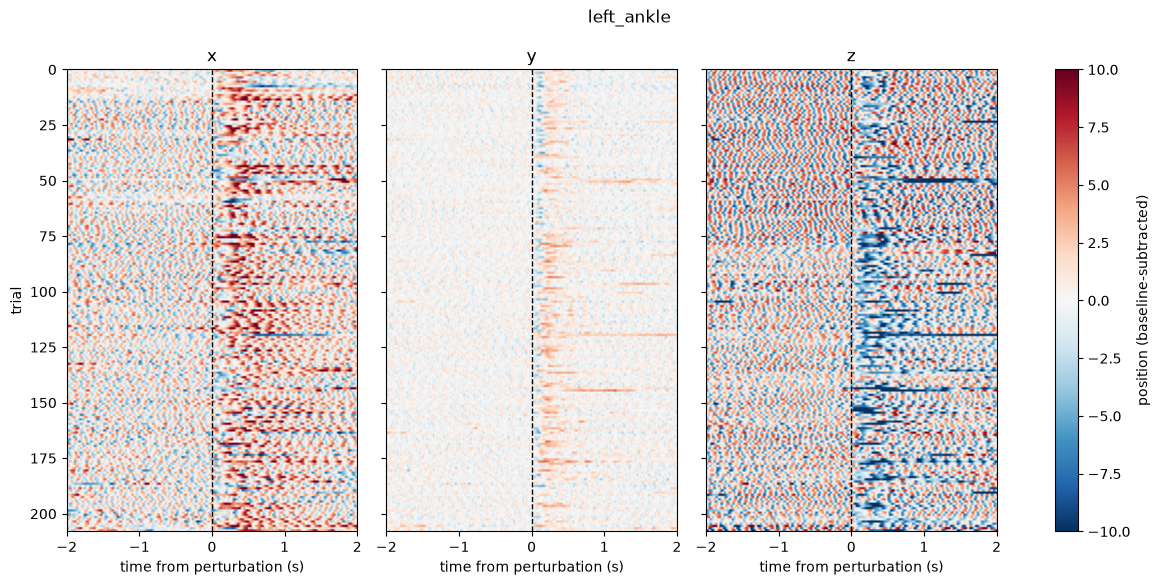

In [133]:
# Heatmap for a single keypoint: trials x time, one column per x/y/z dim.
kp = "left_ankle"
idx = Params.pos_keypoints.index(kp)
start, end = offsets[idx], offsets[idx + 1]
d = end - start

WSPACE = 0.1  # horizontal spacing between subplots

# vmax = np.nanmax(np.abs(Xc[:, :, start:end]))
vmax = 10

fig, axes = plt.subplots(1, d, figsize=(5 * d, 6), sharey=True, gridspec_kw={"wspace": WSPACE})
axes = np.atleast_1d(axes)
for j, ax in enumerate(axes):
    im = ax.imshow(
        Xc[:, :, start + j],
        aspect="auto",
        cmap="RdBu_r",
        vmin=-vmax, vmax=vmax,
        extent=[t[0], t[-1], Xc.shape[0], 0],
    )
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set_title(dim_labels[j] if j < len(dim_labels) else f"dim{j}")
    ax.set_xlabel("time from perturbation (s)")
axes[0].set_ylabel("trial")
fig.suptitle(kp)
fig.colorbar(im, ax=axes.tolist(), label="position (baseline-subtracted)")

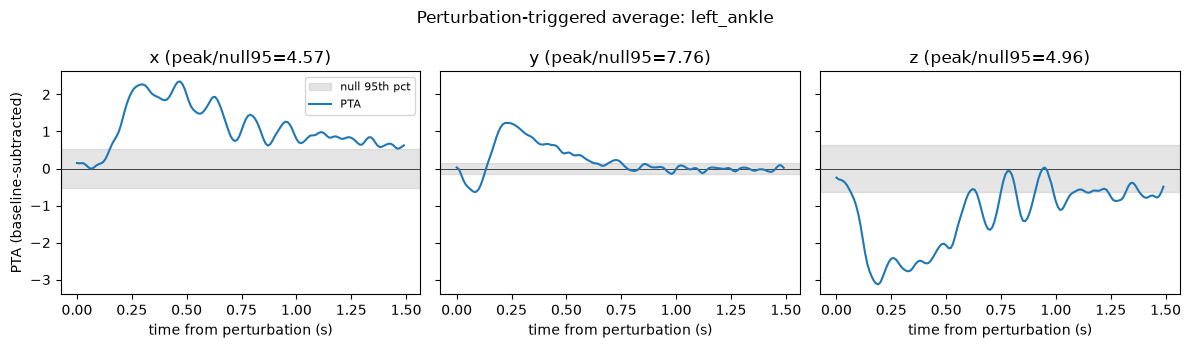

In [72]:
# PTA per dimension for one keypoint, with the shuffle null overlaid as a significance band.
# null95[f] is the 95th percentile of the null peak-|mean| stat (per feature), used symmetrically
# since peak = nanmax(abs(pta)) doesn't care about sign.
kp = "left_ankle"
idx = Params.pos_keypoints.index(kp)
start, end = offsets[idx], offsets[idx + 1]
d = end - start

t_post = (np.arange(pta.shape[0]) + post_sl.start - onset) / FS

fig, axes = plt.subplots(1, d, figsize=(4 * d, 3.5), sharey=True)
axes = np.atleast_1d(axes)
for j, ax in enumerate(axes):
    f = start + j
    ax.axhspan(-null95[f], null95[f], color="gray", alpha=0.2, label="null 95th pct")
    ax.axhline(0, color="k", lw=0.5)
    ax.plot(t_post, pta[:, f], color="C0", lw=1.5, label="PTA")
    ax.set_title(f"{dim_labels[j] if j < len(dim_labels) else f'dim{j}'} (peak/null95={ratio[f]:.2f})")
    ax.set_xlabel("time from perturbation (s)")
axes[0].set_ylabel("PTA (baseline-subtracted)")
axes[0].legend(fontsize=8)
fig.suptitle(f"Perturbation-triggered average: {kp}")
fig.tight_layout()

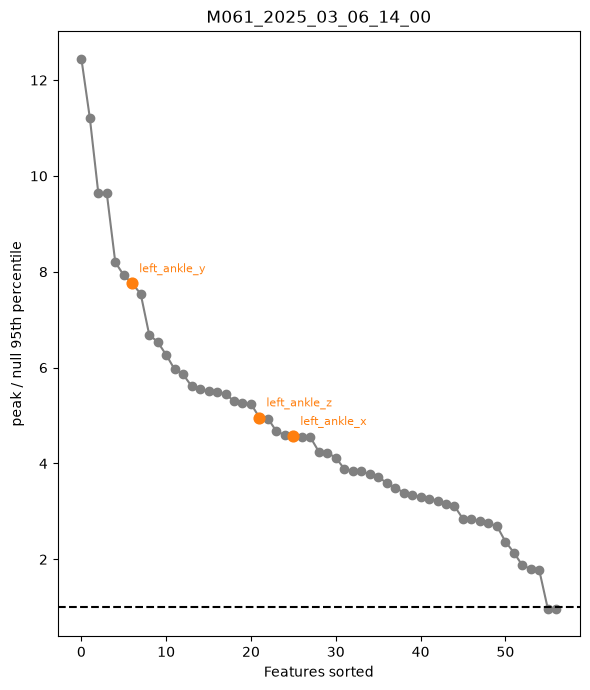

In [76]:
order = np.argsort(-ratio)
fig, ax = plt.subplots(figsize=(6, 7))
ax.plot(ratio[order], marker="o", color="grey", zorder=1)
ax.axhline(1, color="k", ls="--")

# point out left_ankle's x/y/z features within the sorted order
rank_of = {f: pos for pos, f in enumerate(order)}
kp_highlight = "left_ankle"
kp_idx = Params.pos_keypoints.index(kp_highlight)
for f in range(offsets[kp_idx], offsets[kp_idx + 1]):
    pos = rank_of[f]
    ax.scatter(pos, ratio[f], color="C1", zorder=3, s=60)
    ax.annotate(feature_labels[f], (pos, ratio[f]), textcoords="offset points", xytext=(5, 8),
                fontsize=8, color="C1", zorder=4)

ax.set_ylabel("peak / null 95th percentile")
ax.set_xlabel('Features sorted')
ax.set_title(session)
fig.tight_layout()

In [70]:
# Load per-session fraction-of-features-above-chance results saved by
# across-sessions/fraction-above-chance/compute_fraction_above_chance.py
FRAC_DATA = Path('../../across-sessions/fraction-above-chance/data')
fa_files = sorted(FRAC_DATA.glob('*.npz'))

fa_sessions = []
fa_fraction = []
fa_n_above = []
fa_n_features = []
for f in fa_files:
    d = np.load(f, allow_pickle=True)
    fa_sessions.append(str(d['session']))
    fa_fraction.append(float(d['fraction_above_chance']))
    fa_n_above.append(int(d['n_above']))
    fa_n_features.append(int(d['n_features']))

print(f"{len(fa_sessions)} sessions loaded: {fa_sessions}")

11 sessions loaded: ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M063_2025_03_13_14_00', 'M063_2025_03_14_15_30', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']


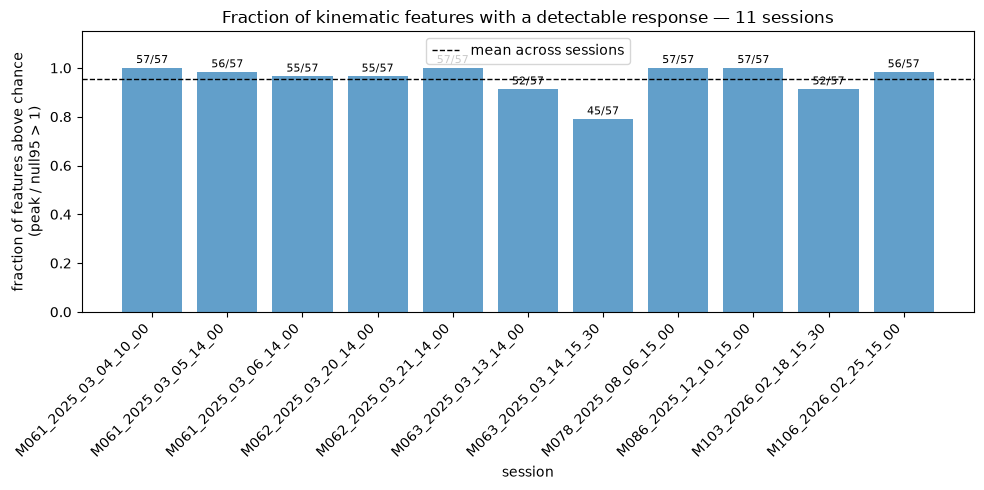

In [71]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(fa_sessions, fa_fraction, color='C0', alpha=0.7)
ax.axhline(np.mean(fa_fraction), color='k', ls='--', lw=1, label='mean across sessions')
for i, (frac, n_above, n_feat) in enumerate(zip(fa_fraction, fa_n_above, fa_n_features)):
    ax.text(i, frac + 0.02, f'{n_above}/{n_feat}', ha='center', fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('fraction of features above chance\n(peak / null95 > 1)')
ax.set_xlabel('session')
ax.set_title(f'Fraction of kinematic features with a detectable response — {len(fa_sessions)} sessions')
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()

## 2. Correlations across trials 

In [4]:
td, by_sem, by_value = dsp.drop_unperturbed_or_stopped_trials(td, return_count=True)
td = dt.add_bhv(td, bhv_fields=["pos_keypoints"])
td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=200)
onset = td.idx_sol_on.values[0]
X = np.stack(td.bhv.values[:])

# comment
base_sl = slice(onset + int(BASE[0] * FS), onset + int(BASE[1] * FS))
post_sl = slice(onset + int(POST[0] * FS), onset + int(POST[1] * FS))
pta, null, Xc = pta_and_null(X, onset, base_sl, post_sl)

  drop_unperturbed_trials: dropped by sem: 36  |  dropped by value: 0  |  kept: 208/244 (85.2%)
bhv field already present, overwriting it


NameError: name 'BASE' is not defined

In [61]:
def trial_corr_vs_null(signal, onset, post_sl, n_shuffle=200, rng=RNG):
    """signal: (n_trials, T). Returns the observed mean pairwise trial correlation in post_sl,
    and a null distribution of the same statistic from pseudo-onsets drawn from the
    pre-perturbation period (same window length) -- so the null reflects the correlation that
    ongoing rhythmic gait alone would produce. np.corrcoef already removes each trial's own mean
    over the window, so (unlike pta_and_null) the pseudo-onset segments don't need rebaselining.
    """
    def mean_offdiag(mat):
        iu = np.triu_indices_from(mat, k=1)
        return np.nanmean(mat[iu])

    obs_stat = mean_offdiag(np.corrcoef(signal[:, post_sl]))

    n_post = post_sl.stop - post_sl.start
    lo, hi = 10, onset - n_post - 5
    null_stats = np.full(n_shuffle, np.nan)
    if hi > lo:
        for s in range(n_shuffle):
            o = rng.integers(lo, hi)
            null_stats[s] = mean_offdiag(np.corrcoef(signal[:, o:o + n_post]))
    return obs_stat, null_stats

In [112]:
idx

<Axes: >

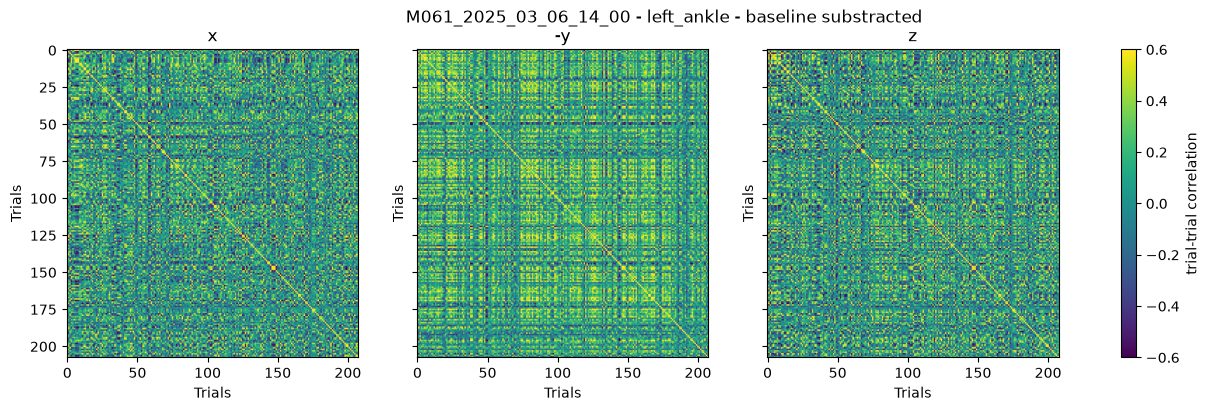

In [138]:
# Detailed look at one keypoint: correlation matrix + observed vs. null histogram, per x/y/z dim
# (using the centered position directly, i.e. Xc, rather than collapsing to speed).
kp = "left_ankle"
idx = Params.pos_keypoints.index(kp)
start, end = offsets[idx], offsets[idx + 1]
d = end - start

fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey='all')
for ax, dim, idx in zip(axs, ('x', '-y', 'z'), np.arange(start, end)):
    corr_mat = np.corrcoef(Xc[:, post_sl, idx])
    im = ax.imshow(
        corr_mat,
        aspect="auto",
        cmap="viridis",
        vmin=-0.6, vmax=0.6,
        # extent=[t[0], t[-1], Xc.shape[0], 0],
    )
    ax.set_title(dim)
    ax.set_xlabel('Trials')
    ax.set_ylabel('Trials')
fig.suptitle(f'{session} - {kp} - baseline substracted ')
fig.colorbar(im, ax=axs.tolist(), label="trial-trial correlation")
plt.show()

In [117]:
obs_f, null_f = trial_corr_vs_null(signal_f, onset, post_sl, n_shuffle=N_SHUFFLE)

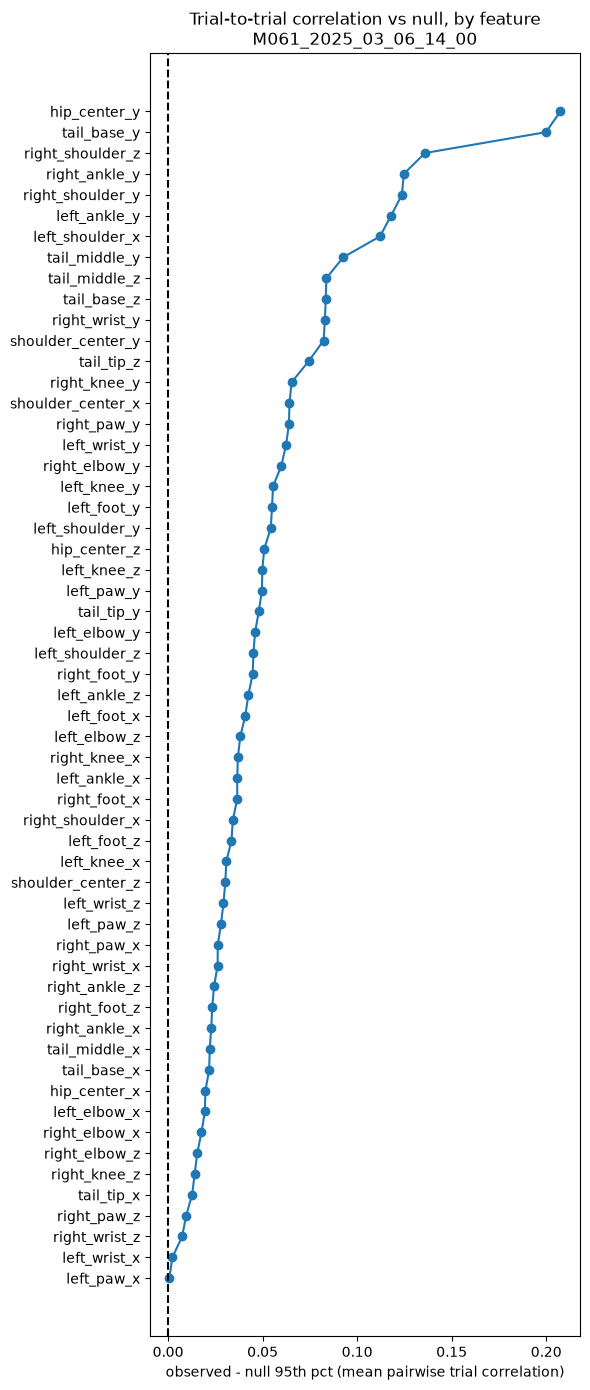

In [104]:
# Same test across all features (x/y/z of every keypoint, using the centered position directly):
# how far above its null 95th pct is each feature's observed trial-to-trial correlation?
# Positive margin = trials more stereotyped than ongoing gait alone.
n_features = Xc.shape[2]
obs_corr_all = np.full(n_features, np.nan)
null95_corr_all = np.full(n_features, np.nan)
for f in range(n_features):
    signal_f = Xc[:, :, f]
    obs_f, null_f = trial_corr_vs_null(signal_f, onset, post_sl, n_shuffle=N_SHUFFLE)
    obs_corr_all[f] = obs_f
    null95_corr_all[f] = np.nanpercentile(null_f, 95)

corr_margin = obs_corr_all - null95_corr_all

order = np.argsort(corr_margin)
fig, ax = plt.subplots(figsize=(6, 14))
ax.plot(corr_margin[order], feature_labels[order], marker="o")
ax.axvline(0, color="k", ls="--")
ax.set_xlabel("observed - null 95th pct (mean pairwise trial correlation)")
ax.set_title(f"Trial-to-trial correlation vs null, by feature\n{session}")
fig.tight_layout()

In [157]:
# For each keypoint's x/y/z dim, get its observed post-perturbation trial correlation and its
# null distribution (trial_corr_vs_null), then collapse across keypoints: one bar per dimension
# for observed and one for null (mean +/- std across keypoints), with individual keypoints
# overlaid as jittered scatter points.
dim_labels = ["x", "-y", "z"]

n_kp = len(Params.pos_keypoints)
mean_corr = np.full((n_kp, len(dim_labels)), np.nan)
null_mean_corr = np.full((n_kp, len(dim_labels)), np.nan)

for k in range(n_kp):
    start_, end_ = offsets[k], offsets[k + 1]
    for j in range(min(end_ - start_, len(dim_labels))):
        f = start_ + j
        obs_kj, null_kj = trial_corr_vs_null(Xc[:, :, f], onset, post_sl, n_shuffle=N_SHUFFLE)
        mean_corr[k, j] = obs_kj
        null_mean_corr[k, j] = np.nanmean(null_kj)

mean_across_kp = np.nanmean(mean_corr, axis=0)
std_across_kp = np.nanstd(mean_corr, axis=0)
null_mean_across_kp = np.nanmean(null_mean_corr, axis=0)
null_std_across_kp = np.nanstd(null_mean_corr, axis=0)

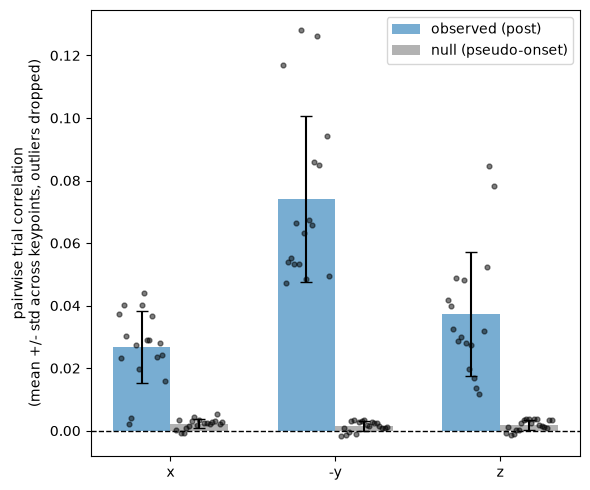

In [158]:
ERROR_TYPE = "std"  # "sem" or "std"

def iqr_mask(x, k=1.5):
    """Boolean mask of non-outlier entries in x, by the 1.5xIQR rule."""
    q1, q3 = np.nanpercentile(x, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (x >= lo) & (x <= hi)

# drop outlier keypoints per dimension (independently for observed and null) before aggregating
mean_corr_filt = mean_corr.copy()
null_mean_corr_filt = null_mean_corr.copy()
for j in range(len(dim_labels)):
    mean_corr_filt[~iqr_mask(mean_corr[:, j]), j] = np.nan
    null_mean_corr_filt[~iqr_mask(null_mean_corr[:, j]), j] = np.nan

mean_across_kp = np.nanmean(mean_corr_filt, axis=0)
std_across_kp = np.nanstd(mean_corr_filt, axis=0)
null_mean_across_kp = np.nanmean(null_mean_corr_filt, axis=0)
null_std_across_kp = np.nanstd(null_mean_corr_filt, axis=0)
n_valid_obs = np.sum(~np.isnan(mean_corr_filt), axis=0)
n_valid_null = np.sum(~np.isnan(null_mean_corr_filt), axis=0)

if ERROR_TYPE == "sem":
    err_obs = std_across_kp / np.sqrt(n_valid_obs)
    err_null = null_std_across_kp / np.sqrt(n_valid_null)
elif ERROR_TYPE == "std":
    err_obs = std_across_kp
    err_null = null_std_across_kp
else:
    raise ValueError(f"unknown ERROR_TYPE: {ERROR_TYPE!r}, expected 'sem' or 'std'")

x_pos = np.arange(len(dim_labels))
bar_width = 0.35
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x_pos - bar_width / 2, mean_across_kp, bar_width, yerr=err_obs, capsize=4,
       label="observed (post)", alpha=0.6, zorder=2)
ax.bar(x_pos + bar_width / 2, null_mean_across_kp, bar_width, yerr=err_null, capsize=4,
       label="null (pseudo-onset)", color="gray", alpha=0.6, zorder=2)

# overlay individual keypoints (outliers excluded), spread across the bar width
jitter = np.linspace(-bar_width / 2 * 0.8, bar_width / 2 * 0.8, n_kp)
for k in range(n_kp):
    ax.scatter(x_pos - bar_width / 2 + jitter[k], mean_corr_filt[k, :], color="k", alpha=0.5, s=12, zorder=3)
    ax.scatter(x_pos + bar_width / 2 + jitter[k], null_mean_corr_filt[k, :], color="k", alpha=0.5, s=12, zorder=3)

ax.axhline(0, color="k", ls="--", lw=1)
ax.set_xticks(x_pos)
ax.set_xticklabels(dim_labels)
ax.set_ylabel(f"pairwise trial correlation\n(mean +/- {ERROR_TYPE} across keypoints, outliers dropped)")
ax.legend()
fig.tight_layout()

In [159]:
# Variance across trials in the post_sl period, per keypoint x/-y/z dim (raw spread, not
# correlation). Same construction as the correlation stat above: collapse each trial to its mean
# position over post_sl, then take the variance of that per-trial value across trials.
var_post = np.full((n_kp, len(dim_labels)), np.nan)
for k in range(n_kp):
    start_, end_ = offsets[k], offsets[k + 1]
    for j in range(min(end_ - start_, len(dim_labels))):
        f = start_ + j
        trial_mean_post = np.nanmean(Xc[:, post_sl, f], axis=1)  # (n_trials,)
        var_post[k, j] = np.nanvar(trial_mean_post)

mean_var_across_kp = np.nanmedian(var_post, axis=0)
std_var_across_kp = np.nanstd(var_post, axis=0)

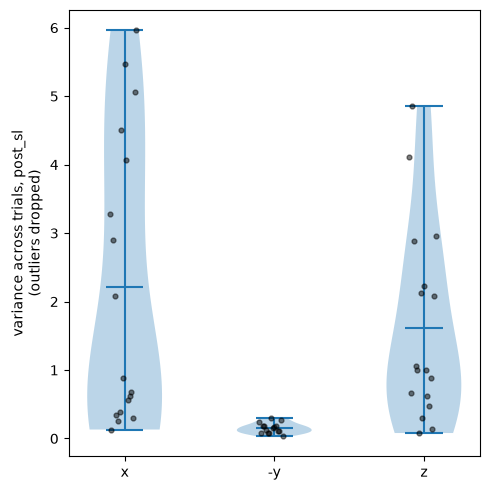

In [160]:
def iqr_mask(x, k=1.5):
    """Boolean mask of non-outlier entries in x, by the 1.5xIQR rule."""
    q1, q3 = np.nanpercentile(x, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (x >= lo) & (x <= hi)

var_post_filt = var_post.copy()
for j in range(len(dim_labels)):
    var_post_filt[~iqr_mask(var_post[:, j]), j] = np.nan

x_pos = np.arange(len(dim_labels))
fig, ax = plt.subplots(figsize=(5, 5))
violin_data = [var_post_filt[:, j][~np.isnan(var_post_filt[:, j])] for j in range(len(dim_labels))]
ax.violinplot(violin_data, positions=x_pos, showmeans=True, showextrema=True)

# overlay individual keypoints (outliers excluded), spread across the violin width
jitter = np.linspace(-0.1, 0.1, n_kp)
for k in range(n_kp):
    ax.scatter(x_pos + jitter[k], var_post_filt[k, :], color="k", alpha=0.5, s=12, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(dim_labels)
ax.set_ylabel("variance across trials, post_sl\n(outliers dropped)")
fig.tight_layout()

## 3. Rotate axes

In [197]:
R, yaw = kin.build_body_frame_td(td)
_ = kin.validate_body_frame_td(td, R, yaw)

  [frame] L/R ml separation: +8.19 (paws), +10.29 (feet); ml dominance 4.7x / 9.8x (needs > 2.0)
  [frame] stride sd [rc,vt,ml] left_paw=[4.79, 1.08, 2.35] right_foot=[7.18, 1.76, 2.72]  (rc dominant, as required)
  [frame] yaw -154.2 +- 8.7 deg (circular; R=0.989, WRAPS +-180); limbs below hip on vt: True


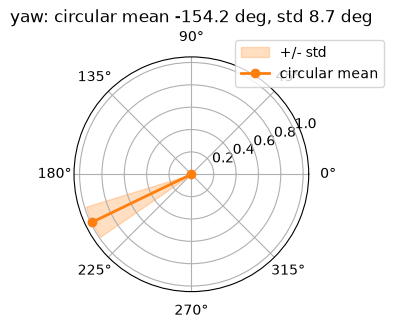

In [191]:
# yaw is circular (wraps at +-180 deg), so use circular mean/std (Rayleigh formula) rather than a
# plain mean/std -- see gaitlib's M078 wraparound issue. R_len (resultant length, 0-1) reflects
# how concentrated the headings are: 1 = all trials face the same way, 0 = uniformly spread.
yaw_rad = np.radians(yaw)
R_len = np.abs(np.nanmean(np.exp(1j * yaw_rad)))
circ_mean = np.angle(np.nanmean(np.exp(1j * yaw_rad)))
circ_std = np.sqrt(-2 * np.log(R_len)) if R_len > 0 else np.nan

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(4, 4))
theta_fill = np.linspace(circ_mean - circ_std, circ_mean + circ_std, 100)
ax.fill_between(theta_fill, 0, R_len, color="C1", alpha=0.25, label="+/- std")
ax.plot([circ_mean, circ_mean], [0, R_len], color="C1", lw=2, marker="o", label="circular mean")
ax.set_rlim(0, 1.05)
ax.set_title(f"yaw: circular mean {np.degrees(circ_mean):+.1f} deg, std {np.degrees(circ_std):.1f} deg")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
fig.tight_layout()

In [16]:
td, _, _ = kin.rotate_bhv_td(td)

  [frame] L/R ml separation: +8.18 (paws), +10.30 (feet); ml dominance 4.4x / 10.2x (needs > 2.0)
  [frame] stride sd [rc,vt,ml] left_paw=[4.78, 1.1, 2.37] right_foot=[7.18, 1.78, 2.72]  (rc dominant, as required)
  [frame] yaw -154.0 +- 8.4 deg (circular; R=0.989, WRAPS +-180); limbs below hip on vt: True


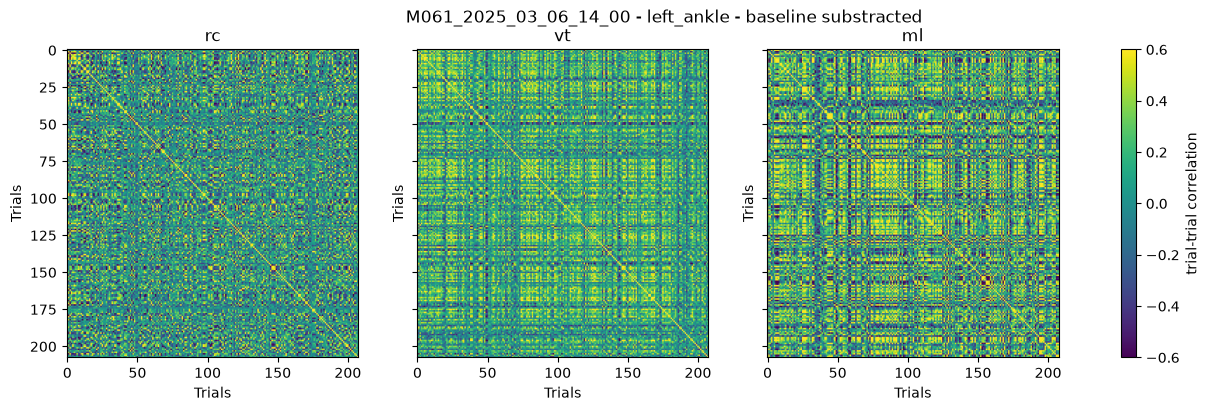

In [56]:
# Detailed look at one keypoint: correlation matrix + observed vs. null histogram, per x/y/z dim
# (using the centered position directly, i.e. Xc, rather than collapsing to speed).
kp_dims = [td[kp].values[0].shape[1] for kp in Params.pos_keypoints]
offsets = np.concatenate(([0], np.cumsum(kp_dims)))
dim_labels = ["rc", "vt", "ml"]

X = np.stack(td.bhv_rot.values)

kp = "left_ankle"
idx = Params.pos_keypoints.index(kp)
start, end = offsets[idx], offsets[idx + 1]
d = end - start

fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey='all')
for ax, dim, idx in zip(axs, dim_labels, np.arange(start, end)):
    corr_mat = np.corrcoef(X[:, post_sl, idx])
    im = ax.imshow(
        corr_mat,
        aspect="auto",
        cmap="viridis",
        vmin=-0.6, vmax=0.6,
        # extent=[t[0], t[-1], Xc.shape[0], 0],
    )
    ax.set_title(dim)
    ax.set_xlabel('Trials')
    ax.set_ylabel('Trials')
fig.suptitle(f'{session} - {kp} - baseline substracted ')
fig.colorbar(im, ax=axs.tolist(), label="trial-trial correlation")
plt.show()

In [62]:
# For each keypoint's x/y/z dim, get its observed post-perturbation trial correlation and its
# null distribution (trial_corr_vs_null), then collapse across keypoints: one bar per dimension
# for observed and one for null (mean +/- std across keypoints), with individual keypoints
# overlaid as jittered scatter points.

n_kp = len(Params.pos_keypoints)
mean_corr = np.full((n_kp, len(dim_labels)), np.nan)
null_mean_corr = np.full((n_kp, len(dim_labels)), np.nan)

for k in range(n_kp):
    start_, end_ = offsets[k], offsets[k + 1]
    for j in range(min(end_ - start_, len(dim_labels))):
        f = start_ + j
        obs_kj, null_kj = trial_corr_vs_null(X[:, :, f], onset, post_sl, n_shuffle=N_SHUFFLE)
        mean_corr[k, j] = obs_kj
        null_mean_corr[k, j] = np.nanmean(null_kj)

mean_across_kp = np.nanmean(mean_corr, axis=0)
std_across_kp = np.nanstd(mean_corr, axis=0)
null_mean_across_kp = np.nanmean(null_mean_corr, axis=0)
null_std_across_kp = np.nanstd(null_mean_corr, axis=0)

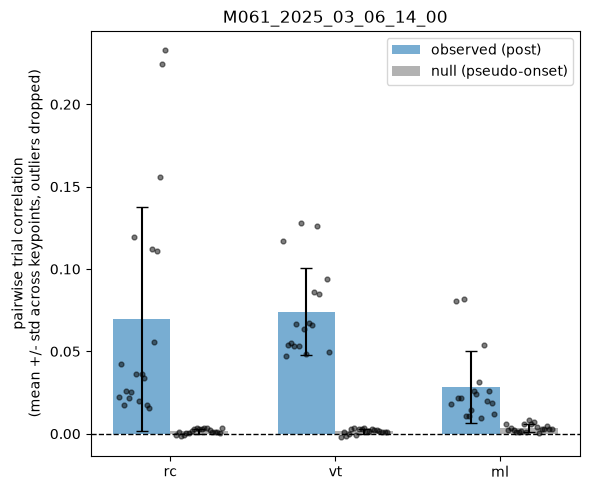

In [63]:
ERROR_TYPE = "std"  # "sem" or "std"

def iqr_mask(x, k=1.5):
    """Boolean mask of non-outlier entries in x, by the 1.5xIQR rule."""
    q1, q3 = np.nanpercentile(x, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (x >= lo) & (x <= hi)

# drop outlier keypoints per dimension (independently for observed and null) before aggregating
mean_corr_filt = mean_corr.copy()
null_mean_corr_filt = null_mean_corr.copy()
for j in range(len(dim_labels)):
    mean_corr_filt[~iqr_mask(mean_corr[:, j]), j] = np.nan
    null_mean_corr_filt[~iqr_mask(null_mean_corr[:, j]), j] = np.nan

mean_across_kp = np.nanmean(mean_corr_filt, axis=0)
std_across_kp = np.nanstd(mean_corr_filt, axis=0)
null_mean_across_kp = np.nanmean(null_mean_corr_filt, axis=0)
null_std_across_kp = np.nanstd(null_mean_corr_filt, axis=0)
n_valid_obs = np.sum(~np.isnan(mean_corr_filt), axis=0)
n_valid_null = np.sum(~np.isnan(null_mean_corr_filt), axis=0)

if ERROR_TYPE == "sem":
    err_obs = std_across_kp / np.sqrt(n_valid_obs)
    err_null = null_std_across_kp / np.sqrt(n_valid_null)
elif ERROR_TYPE == "std":
    err_obs = std_across_kp
    err_null = null_std_across_kp
else:
    raise ValueError(f"unknown ERROR_TYPE: {ERROR_TYPE!r}, expected 'sem' or 'std'")

x_pos = np.arange(len(dim_labels))
bar_width = 0.35
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x_pos - bar_width / 2, mean_across_kp, bar_width, yerr=err_obs, capsize=4,
       label="observed (post)", alpha=0.6, zorder=2)
ax.bar(x_pos + bar_width / 2, null_mean_across_kp, bar_width, yerr=err_null, capsize=4,
       label="null (pseudo-onset)", color="gray", alpha=0.6, zorder=2)

# overlay individual keypoints (outliers excluded), spread across the bar width
jitter = np.linspace(-bar_width / 2 * 0.8, bar_width / 2 * 0.8, n_kp)
for k in range(n_kp):
    ax.scatter(x_pos - bar_width / 2 + jitter[k], mean_corr_filt[k, :], color="k", alpha=0.5, s=12, zorder=3)
    ax.scatter(x_pos + bar_width / 2 + jitter[k], null_mean_corr_filt[k, :], color="k", alpha=0.5, s=12, zorder=3)

ax.axhline(0, color="k", ls="--", lw=1)
ax.set_xticks(x_pos)
ax.set_xticklabels(dim_labels)
ax.set_ylabel(f"pairwise trial correlation\n(mean +/- {ERROR_TYPE} across keypoints, outliers dropped)")
ax.legend()
ax.set_title(session)
fig.tight_layout()

In [64]:
# Variance across trials in the post_sl period, per keypoint x/-y/z dim (raw spread, not
# correlation). Same construction as the correlation stat above: collapse each trial to its mean
# position over post_sl, then take the variance of that per-trial value across trials.
var_post = np.full((n_kp, len(dim_labels)), np.nan)
for k in range(n_kp):
    start_, end_ = offsets[k], offsets[k + 1]
    for j in range(min(end_ - start_, len(dim_labels))):
        f = start_ + j
        trial_mean_post = np.nanmean(X[:, post_sl, f], axis=1)  # (n_trials,)
        var_post[k, j] = np.nanvar(trial_mean_post)

mean_var_across_kp = np.nanmedian(var_post, axis=0)
std_var_across_kp = np.nanstd(var_post, axis=0)

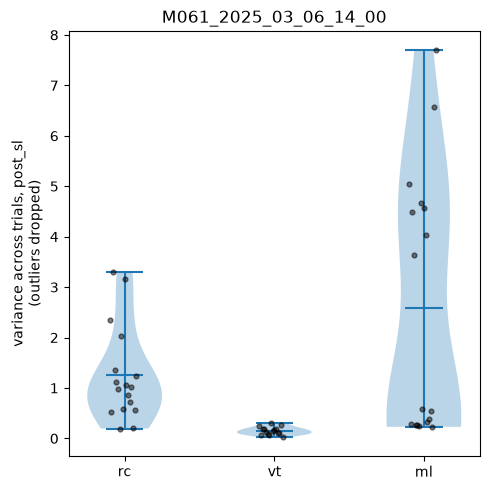

In [66]:
def iqr_mask(x, k=1.5):
    """Boolean mask of non-outlier entries in x, by the 1.5xIQR rule."""
    q1, q3 = np.nanpercentile(x, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (x >= lo) & (x <= hi)

var_post_filt = var_post.copy()
for j in range(len(dim_labels)):
    var_post_filt[~iqr_mask(var_post[:, j]), j] = np.nan

x_pos = np.arange(len(dim_labels))
fig, ax = plt.subplots(figsize=(5, 5))
violin_data = [var_post_filt[:, j][~np.isnan(var_post_filt[:, j])] for j in range(len(dim_labels))]
ax.violinplot(violin_data, positions=x_pos, showmeans=True, showextrema=True)

# overlay individual keypoints (outliers excluded), spread across the violin width
jitter = np.linspace(-0.1, 0.1, n_kp)
for k in range(n_kp):
    ax.scatter(x_pos + jitter[k], var_post_filt[k, :], color="k", alpha=0.5, s=12, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(dim_labels)
ax.set_ylabel("variance across trials, post_sl\n(outliers dropped)")
ax.set_title(session)
fig.tight_layout()

In [49]:
# Load per-session running-direction (yaw) stats saved by
# across-sessions/running-direction/compute_running_direction.py
RUN_DIR_DATA = Path('../../across-sessions/running-direction/data')
rd_files = sorted(RUN_DIR_DATA.glob('*.npz'))

rd_sessions = []
rd_circ_mean = []
rd_circ_std = []
for f in rd_files:
    d = np.load(f, allow_pickle=True)
    rd_sessions.append(str(d['session']))
    rd_circ_mean.append(float(d['circ_mean_deg']))
    rd_circ_std.append(float(d['circ_std_deg']))

print(f"{len(rd_sessions)} sessions loaded: {rd_sessions}")

11 sessions loaded: ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M063_2025_03_13_14_00', 'M063_2025_03_14_15_30', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']


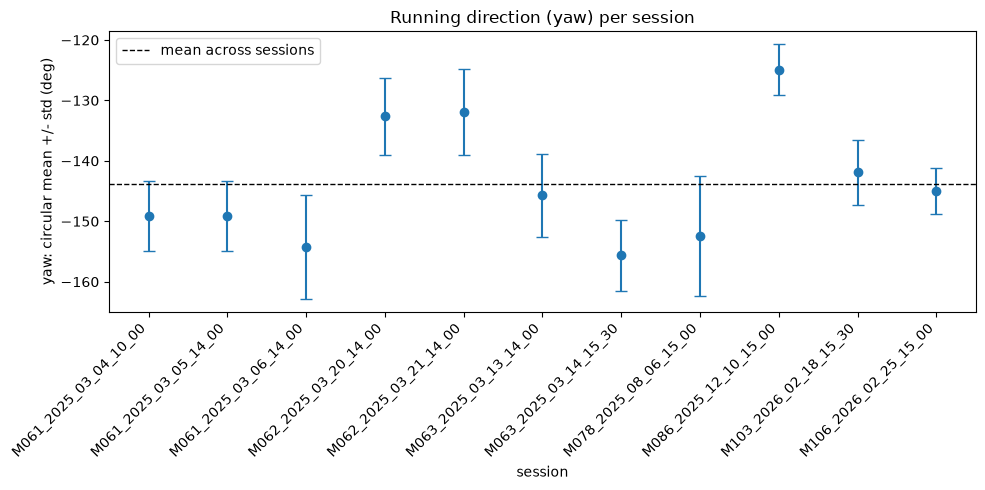

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(rd_sessions, rd_circ_mean, yerr=rd_circ_std, fmt='o', capsize=4)
ax.axhline(np.mean(rd_circ_mean), color='k', ls='--', lw=1, label='mean across sessions')
ax.set_ylabel('yaw: circular mean +/- std (deg)')
ax.set_xlabel('session')
ax.set_title('Running direction (yaw) per session')
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()

In [67]:
# Load per-session trial-trial correlation (body-relative rc/vt/ml) results saved by
# across-sessions/trial-correlations/compute_trial_correlations.py
TRIAL_CORR_DATA = Path('../../across-sessions/trial-correlations/data')
tc_files = sorted(TRIAL_CORR_DATA.glob('*.npz'))

tc_sessions = []
tc_obs_per_session = []   # per session: (3,) mean observed corr across keypoints, per dim
tc_null_per_session = []  # per session: (3,) mean null corr across keypoints, per dim
tc_dim_labels = None

for f in tc_files:
    d = np.load(f, allow_pickle=True)
    tc_sessions.append(str(d['session']))
    tc_obs_per_session.append(np.nanmean(d['obs_corr'], axis=0))
    tc_null_per_session.append(np.nanmean(d['null_mean'], axis=0))
    if tc_dim_labels is None:
        tc_dim_labels = list(d['dim_labels'])

tc_obs_per_session = np.stack(tc_obs_per_session)    # (n_sessions, 3)
tc_null_per_session = np.stack(tc_null_per_session)  # (n_sessions, 3)

print(f"{len(tc_sessions)} sessions loaded: {tc_sessions}")

11 sessions loaded: ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M063_2025_03_13_14_00', 'M063_2025_03_14_15_30', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']


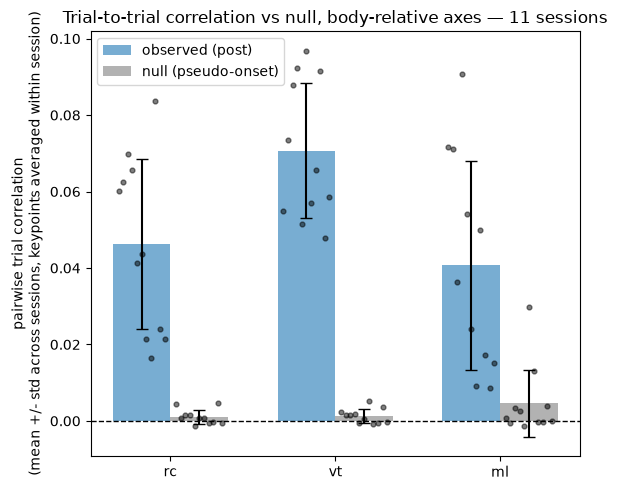

In [68]:
x_pos = np.arange(len(tc_dim_labels))
bar_width = 0.35

obs_mean = tc_obs_per_session.mean(axis=0)
obs_std = tc_obs_per_session.std(axis=0)
null_mean = tc_null_per_session.mean(axis=0)
null_std = tc_null_per_session.std(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x_pos - bar_width / 2, obs_mean, bar_width, yerr=obs_std, capsize=4,
       label='observed (post)', alpha=0.6, zorder=2)
ax.bar(x_pos + bar_width / 2, null_mean, bar_width, yerr=null_std, capsize=4,
       label='null (pseudo-onset)', color='gray', alpha=0.6, zorder=2)

# overlay individual sessions (each already averaged across its own keypoints)
jitter = np.linspace(-bar_width / 2 * 0.8, bar_width / 2 * 0.8, len(tc_sessions))
for i in range(len(tc_sessions)):
    ax.scatter(x_pos - bar_width / 2 + jitter[i], tc_obs_per_session[i], color='k', alpha=0.5, s=12, zorder=3)
    ax.scatter(x_pos + bar_width / 2 + jitter[i], tc_null_per_session[i], color='k', alpha=0.5, s=12, zorder=3)

ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xticks(x_pos)
ax.set_xticklabels(tc_dim_labels)
ax.set_ylabel('pairwise trial correlation\n(mean +/- std across sessions, keypoints averaged within session)')
ax.set_title(f'Trial-to-trial correlation vs null, body-relative axes — {len(tc_sessions)} sessions')
ax.legend()
fig.tight_layout()

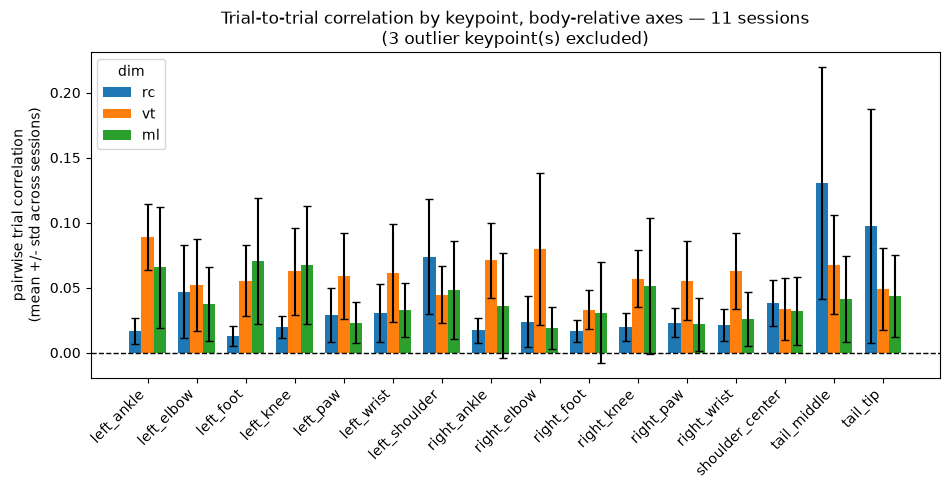

In [69]:
# Same data, broken out by keypoint instead of collapsed to one number per session: for each
# keypoint, mean +/- std (across sessions) of its observed post-perturbation trial correlation,
# grouped as rc/vt/ml bars. Keypoints that are IQR outliers (across keypoints) on ANY of the
# three axes are excluded, same rule as the single-session cell above (`iqr_mask`).
tc_obs_by_kp = []  # per session: (n_kp, 3)
tc_keypoints = None
for f in tc_files:
    d = np.load(f, allow_pickle=True)
    tc_obs_by_kp.append(d['obs_corr'])
    if tc_keypoints is None:
        tc_keypoints = list(d['keypoints'])

tc_obs_by_kp = np.stack(tc_obs_by_kp)                    # (n_sessions, n_kp, 3)
kp_mean_across_sessions = np.nanmean(tc_obs_by_kp, axis=0)  # (n_kp, 3)
kp_std_across_sessions = np.nanstd(tc_obs_by_kp, axis=0)    # (n_kp, 3)

keep_mask = np.ones(len(tc_keypoints), dtype=bool)
for j in range(kp_mean_across_sessions.shape[1]):
    keep_mask &= iqr_mask(kp_mean_across_sessions[:, j])

kp_names_kept = np.array(tc_keypoints)[keep_mask]
kp_mean_kept = kp_mean_across_sessions[keep_mask]
kp_std_kept = kp_std_across_sessions[keep_mask]

x_pos = np.arange(len(kp_names_kept))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(max(8, len(kp_names_kept) * 0.6), 5))
for j, dim in enumerate(tc_dim_labels):
    offset = (j - 1) * bar_width
    ax.bar(x_pos + offset, kp_mean_kept[:, j], bar_width, yerr=kp_std_kept[:, j], capsize=3, label=dim)

ax.set_xticks(x_pos)
ax.set_xticklabels(kp_names_kept, rotation=45, ha='right')
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_ylabel('pairwise trial correlation\n(mean +/- std across sessions)')
ax.set_title(
    f'Trial-to-trial correlation by keypoint, body-relative axes — {len(tc_sessions)} sessions\n'
    f'({(~keep_mask).sum()} outlier keypoint(s) excluded)'
)
ax.legend(title='dim')
fig.tight_layout()

## 4. Decode solenoid ID

In [4]:
FS = 100
BASE = (-1.6, -0.1)     # baseline window (s, rel. onset)
POST = (0.0, 1.5)       # response window
N_SHUFFLE = 200

In [5]:
td, by_sem, by_value = dsp.drop_unperturbed_or_stopped_trials(td, return_count=True)
td = dt.add_bhv(td, bhv_fields=["pos_keypoints"])
td = pyal.restrict_to_interval(td, start_point_name='idx_sol_on', rel_start=-200, rel_end=200)
onset = td.idx_sol_on.values[0]

# comment
base_sl = slice(onset + int(BASE[0] * FS), onset + int(BASE[1] * FS))
post_sl = slice(onset + int(POST[0] * FS), onset + int(POST[1] * FS))


td, _, _ = kin.rotate_bhv_td(td)
X_ = np.stack(td.bhv_rot.values[:])


  drop_unperturbed_trials: dropped by sem: 36  |  dropped by value: 0  |  kept: 208/244 (85.2%)
bhv field already present, overwriting it
  [frame] L/R ml separation: +8.19 (paws), +10.29 (feet); ml dominance 4.7x / 9.8x (needs > 2.0)
  [frame] stride sd [rc,vt,ml] left_paw=[4.79, 1.08, 2.35] right_foot=[7.18, 1.76, 2.72]  (rc dominant, as required)
  [frame] yaw -154.2 +- 8.7 deg (circular; R=0.989, WRAPS +-180); limbs below hip on vt: True


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB

X = X_[:, post_sl, :]
n_trials, n_time, n_features = X.shape

scores = cross_val_score(
    LinearDiscriminantAnalysis(),
    X=X.reshape(n_trials, -1),
    y=td.values_Sol_direction.values.tolist(),
    cv=KFold(5),
    scoring='accuracy'
)
scores.mean()


scores_cont, time = decode.moving_window_decoding(
    X_,
    td.values_Sol_direction.values.tolist()
)

100%|██████████| 71/71 [00:09<00:00,  7.56it/s]


Text(0.5, 0.98, 'M061_2025_03_06_14_00 Decoding sol ID from rotate bhv keypoints')

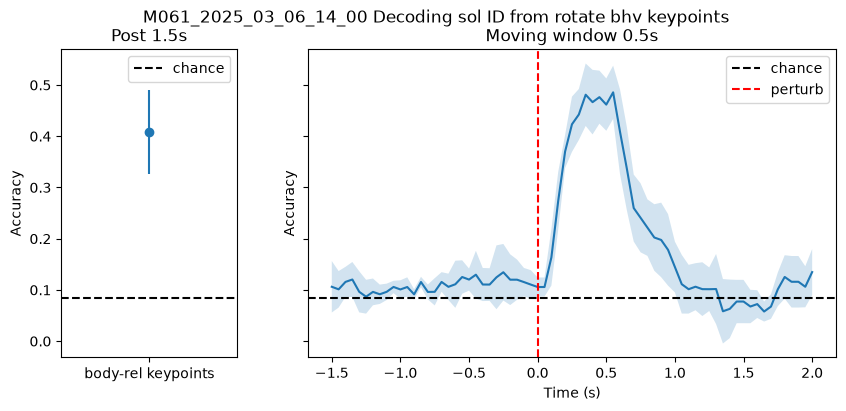

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 3]}, sharey='all')
vizutils.shaded_errorbar(axs[1], time-2, scores_cont)
axs[1].axhline(1/12, label='chance', c='k', ls='--')
axs[1].axvline(0, label='perturb', c='r', ls='--')
axs[1].set_title('Moving window 0.5s')
axs[1].set_xlabel('Time (s)')
axs[0].set_ylabel('Accuracy')
axs[1].set_ylabel('Accuracy')

axs[1].legend()

axs[0].errorbar(['body-rel keypoints'], scores.mean(), marker='o', yerr=scores.std())
axs[0].axhline(1/12, label='chance', c='k', ls='--')
axs[0].legend()
axs[0].set_title('Post 1.5s')
plt.suptitle(f'{session} Decoding sol ID from rotate bhv keypoints')

#### All sessions

In [44]:
# Load the per-session decoding results saved by
# across-sessions/bhv-decode-solenoid/decode_solenoid_direction.py
DATA_DIR = Path('../../across-sessions/bhv-decode-solenoid/data')
npz_files = sorted(DATA_DIR.glob('*.npz'))

sessions_all = []
fixed_scores_all = []   # per session: (n_folds,) LDA accuracy, POST window
moving_scores_all = []  # per session: (n_windows,) GaussianNB accuracy, mean across folds
moving_time_s = None
chance = None

for f in npz_files:
    d = np.load(f, allow_pickle=True)
    sessions_all.append(str(d['session']))
    fixed_scores_all.append(d['fixed_scores'])
    moving_scores_all.append(d['moving_scores'].mean(axis=1))
    if moving_time_s is None:
        moving_time_s = d['moving_time_s']
    chance = float(d['chance'])

fixed_scores_all = np.stack(fixed_scores_all)     # (n_sessions, n_folds)
moving_scores_all = np.stack(moving_scores_all)   # (n_sessions, n_windows)

print(f"{len(sessions_all)} sessions loaded: {sessions_all}")

9 sessions loaded: ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']


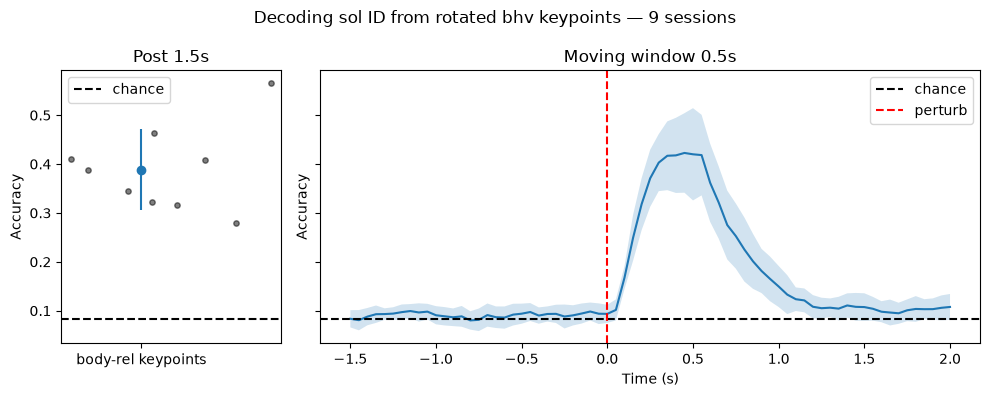

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 3]}, sharey='all')

# right: moving-window accuracy, mean +/- std ACROSS SESSIONS at each time point
vizutils.shaded_errorbar(axs[1], moving_time_s, moving_scores_all.T)
axs[1].axhline(chance, label='chance', c='k', ls='--')
axs[1].axvline(0, label='perturb', c='r', ls='--')
axs[1].set_title('Moving window 0.5s')
axs[1].set_xlabel('Time (s)')
axs[0].set_ylabel('Accuracy')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

# left: fixed post-window accuracy, mean +/- std across sessions, per-session means overlaid
per_session_fixed_mean = fixed_scores_all.mean(axis=1)
jitter = np.random.default_rng(0).normal(0, 0.02, size=len(per_session_fixed_mean))
axs[0].errorbar(['body-rel keypoints'], per_session_fixed_mean.mean(), marker='o',
                 yerr=per_session_fixed_mean.std(), zorder=2)
axs[0].scatter(jitter, per_session_fixed_mean, color='k', alpha=0.5, s=15, zorder=3)
axs[0].axhline(chance, label='chance', c='k', ls='--')
axs[0].legend()
axs[0].set_title('Post 1.5s')

plt.suptitle(f'Decoding sol ID from rotated bhv keypoints — {len(sessions_all)} sessions')
fig.tight_layout()

## 5. Are there discrete patterns of activity?

In [72]:
# ============================================================
# PCA + KMeans backbone: cluster trials directly on rotated (rc/vt/ml) kinematics
# ============================================================
# Same feature representation as the decoding cells above (X_, post_sl, td.bhv_rot) -- one row
# per trial, the flattened (time x keypoint-dim) values in the POST window. sklearn expects a 2D
# (n_samples, n_features) array, so we reshape the (n_trials, n_time, n_features) block.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_clust = X_[:, post_sl, :]
n_trials, n_time, n_features = X_clust.shape
X_flat = X_clust.reshape(n_trials, -1)          # (n_trials, n_time * n_features)

# z-score each column: without this, keypoints/timepoints with larger raw amplitude would
# dominate the distance metric that PCA/KMeans use, regardless of whether they carry more signal.
X_scaled = StandardScaler().fit_transform(X_flat)
print(f"{n_trials} trials, {X_flat.shape[1]} raw features -> standardized")

208 trials, 8550 raw features -> standardized


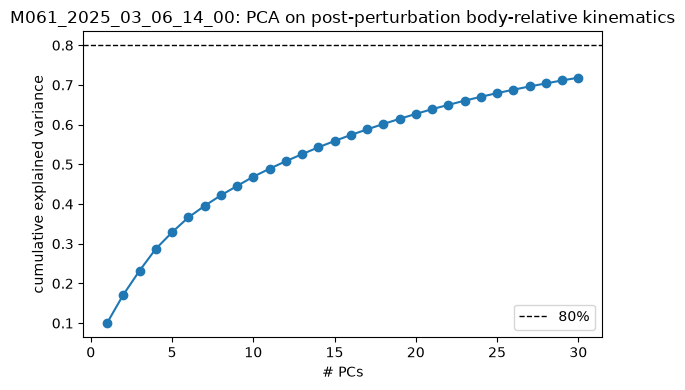

In [85]:
# PCA: with ~8500 raw features and only ~200 trials, clustering directly on X_scaled would mostly
# fit noise (curse of dimensionality). Reducing to a handful of PCs first keeps only the
# directions of largest shared variance across trials -- exactly what a clustering algorithm
# should be grouping trials by.
pca = PCA(n_components=30, random_state=0)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
        np.cumsum(pca.explained_variance_ratio_), marker='o')
ax.axhline(0.8, color='k', ls='--', lw=1, label='80%')
ax.set_xlabel('# PCs')
ax.set_ylabel('cumulative explained variance')
ax.set_title(f'{session}: PCA on post-perturbation body-relative kinematics')
ax.legend()
fig.tight_layout()

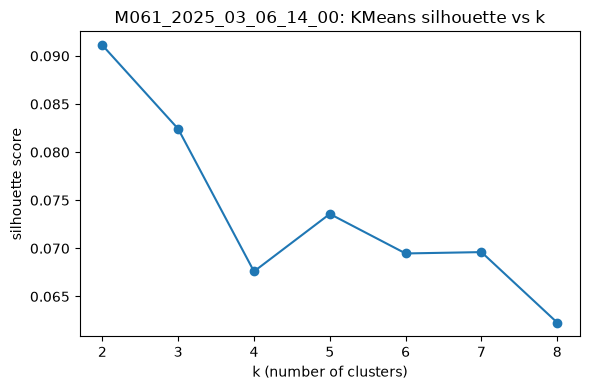

In [86]:
# KMeans needs k chosen in advance. Sweep a small range and score each with the silhouette
# coefficient (how much closer, on average, each point is to its own cluster than to the next
# closest one; ranges -1..1, higher = better-separated clusters). This alone does NOT prove real
# clusters exist -- see the null check below -- it's only a way to compare candidate k values.
K_RANGE = range(2, 9)
sil_scores = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K_RANGE), sil_scores, marker='o')
ax.set_xlabel('k (number of clusters)')
ax.set_ylabel('silhouette score')
ax.set_title(f'{session}: KMeans silhouette vs k')
fig.tight_layout()

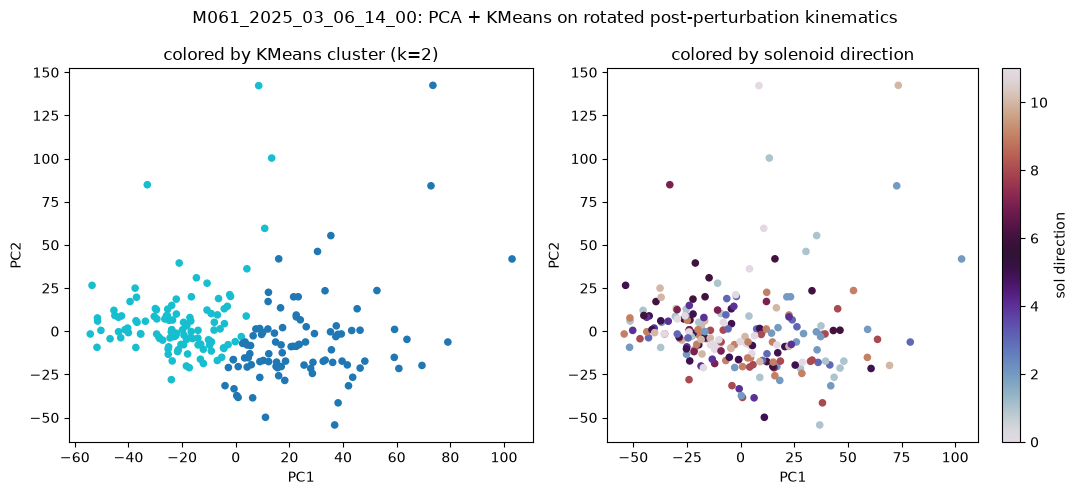

In [87]:
# Fit KMeans at the best-silhouette k and look at the result in PC space: does it look like real
# clusters (separated blobs), or does it look like KMeans cutting a continuum in half? Compare
# against solenoid direction too -- if clusters tracked the stimulus we'd see color blocks on the
# right that line up with the groups on the left.
k_best = list(K_RANGE)[int(np.argmax(sil_scores))]
km = KMeans(n_clusters=k_best, n_init=10, random_state=0)
cluster_labels = km.fit_predict(X_pca)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', s=20)
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title(f'colored by KMeans cluster (k={k_best})')

sol_dir = td.values_Sol_direction.values.astype(float)
sc1 = axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=sol_dir, cmap='twilight', s=20)
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC2')
axs[1].set_title('colored by solenoid direction')
fig.colorbar(sc1, ax=axs[1], label='sol direction')

plt.suptitle(f'{session}: PCA + KMeans on rotated post-perturbation kinematics')
fig.tight_layout()

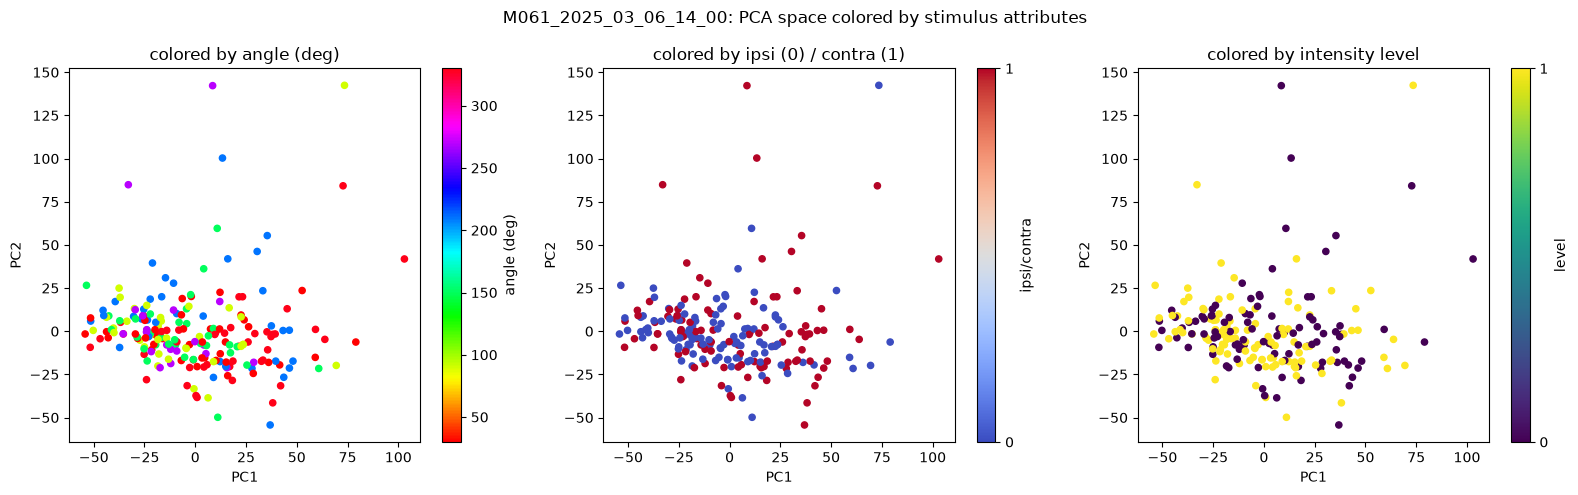

In [83]:
# More views of the same PC1/PC2 space, colored by other stimulus attributes derived from
# solenoid direction (tools/params.py::Params): angle (6 distinct headings, circular -- hence the
# hsv colormap), ipsi/contra laterality, and intensity level. If clusters were tracking any of
# these instead of the "trials form a continuum" picture above, it would show up here as color
# blocks lining up with structure in PC space.
sol_angle = np.array([Params.sol_dir_to_angle[int(d)] for d in sol_dir])
sol_contra_ipsi = td.sol_contra_ipsi.values.astype(float)
sol_level = td.sol_level_id.values.astype(float)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

sc0 = axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=sol_angle, cmap='hsv', s=20)
axs[0].set_title('colored by angle (deg)')
fig.colorbar(sc0, ax=axs[0], label='angle (deg)')

sc1 = axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=sol_contra_ipsi, cmap='coolwarm', s=20)
axs[1].set_title('colored by ipsi (0) / contra (1)')
fig.colorbar(sc1, ax=axs[1], ticks=[0, 1], label='ipsi/contra')

sc2 = axs[2].scatter(X_pca[:, 0], X_pca[:, 1], c=sol_level, cmap='viridis', s=20)
axs[2].set_title('colored by intensity level')
fig.colorbar(sc2, ax=axs[2], ticks=[0, 1], label='level')

for ax in axs:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle(f'{session}: PCA space colored by stimulus attributes')
fig.tight_layout()

In [88]:
# A high silhouette can still show up on data with NO real cluster structure -- KMeans always
# finds *some* partition, and unstructured (e.g. Gaussian) data isn't perfectly uniform, so the
# best split of it still scores above 0. To tell "real clusters" from "KMeans dividing a
# continuum," compare the observed silhouette to a null built by permuting each PC independently
# across trials: this keeps every PC's own distribution/scale but destroys any real relationship
# BETWEEN PCs, i.e. destroys genuine multivariate cluster structure while changing nothing else.
rng = np.random.default_rng(0)
n_null = 50
null_sil = []
for _ in range(n_null):
    X_shuff = np.column_stack([rng.permutation(X_pca[:, j]) for j in range(X_pca.shape[1])])
    km_null = KMeans(n_clusters=k_best, n_init=10, random_state=0)
    labels_null = km_null.fit_predict(X_shuff)
    null_sil.append(silhouette_score(X_shuff, labels_null))

obs_sil = sil_scores[int(np.argmax(sil_scores))]
p_val = (np.sum(np.array(null_sil) >= obs_sil) + 1) / (n_null + 1)
print(f"k={k_best}: observed silhouette={obs_sil:.3f}, "
      f"null 95th pct={np.percentile(null_sil, 95):.3f}, p={p_val:.3f}")

k=2: observed silhouette=0.091, null 95th pct=0.099, p=0.392


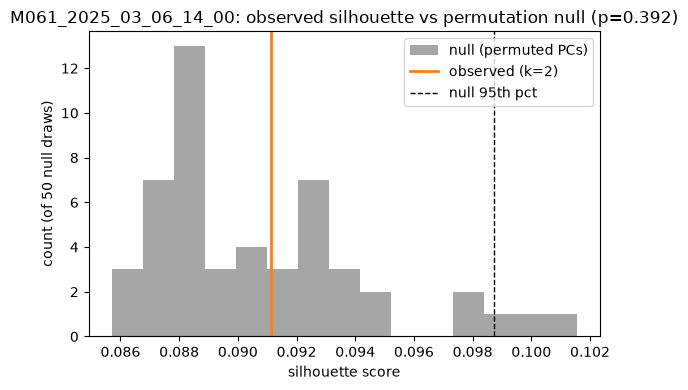

In [89]:
# Visualize that comparison directly: histogram of the null silhouette scores (what KMeans
# achieves on data with no real multivariate structure, just the same per-PC marginals), with the
# observed silhouette overlaid. If the orange line sat out in the right tail, past the null's 95th
# percentile, that would be evidence of real cluster structure -- here it sits in the middle of the
# null distribution, visually matching the p=0.31 above.
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(null_sil, bins=15, color='gray', alpha=0.7, label='null (permuted PCs)')
ax.axvline(obs_sil, color='C1', lw=2, label=f'observed (k={k_best})')
ax.axvline(np.percentile(null_sil, 95), color='k', ls='--', lw=1, label='null 95th pct')
ax.set_xlabel('silhouette score')
ax.set_ylabel('count (of 50 null draws)')
ax.set_title(f'{session}: observed silhouette vs permutation null (p={p_val:.3f})')
ax.legend()
fig.tight_layout()

In [90]:
# Load per-session clustering results saved by
# across-sessions/clustering/compute_clustering.py
CLUSTER_DATA = Path('../../across-sessions/clustering/data')
cl_files = sorted(CLUSTER_DATA.glob('*.npz'))

cl_sessions = []
cl_k_best = []
cl_obs_sil = []
cl_null95 = []
cl_p_value = []
cl_null_sil = []  # per session: (N_NULL,) full null distribution
for f in cl_files:
    d = np.load(f, allow_pickle=True)
    cl_sessions.append(str(d['session']))
    cl_k_best.append(int(d['k_best']))
    cl_obs_sil.append(float(d['obs_sil']))
    cl_null95.append(float(d['null95']))
    cl_p_value.append(float(d['p_value']))
    cl_null_sil.append(d['null_sil'])

print(f"{len(cl_sessions)} sessions loaded: {cl_sessions}")

11 sessions loaded: ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M063_2025_03_13_14_00', 'M063_2025_03_14_15_30', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']


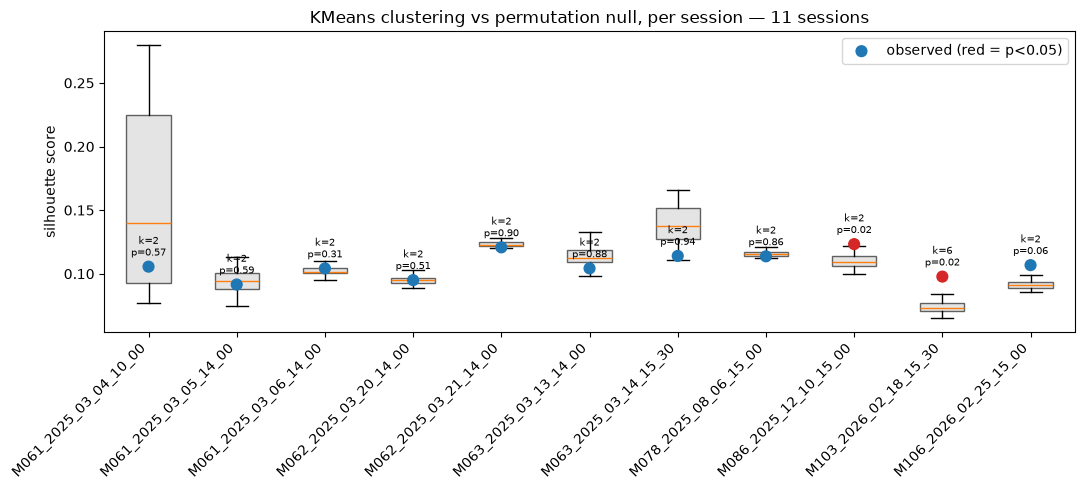

In [91]:
# Per-session version of the null-vs-observed histogram above: null distribution as a boxplot,
# observed silhouette as a dot (red if it beats its own null at p<0.05), k_best/p annotated.
# 11 independent tests at alpha=0.05 would give ~0.5 false positives by chance alone, so treat any
# single red dot here with that in mind rather than as proof of a real cluster in that session.
fig, ax = plt.subplots(figsize=(11, 5))

bp = ax.boxplot(cl_null_sil, positions=np.arange(len(cl_sessions)), widths=0.5,
                 patch_artist=True, showfliers=False)
for box in bp['boxes']:
    box.set(facecolor='lightgray', alpha=0.6)

sig = np.array(cl_p_value) < 0.05
colors = np.where(sig, 'C3', 'C0')
ax.scatter(np.arange(len(cl_sessions)), cl_obs_sil, c=colors, zorder=3, s=60,
           label='observed (red = p<0.05)')

for i, (k, p) in enumerate(zip(cl_k_best, cl_p_value)):
    ax.annotate(f'k={k}\np={p:.2f}', (i, cl_obs_sil[i]), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=7)

ax.set_xticks(np.arange(len(cl_sessions)))
ax.set_xticklabels(cl_sessions, rotation=45, ha='right')
ax.set_ylabel('silhouette score')
ax.set_title(f'KMeans clustering vs permutation null, per session — {len(cl_sessions)} sessions')
ax.legend()
fig.tight_layout()